In [2]:
#特征工程

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 设置pandas显示选项，确保不省略任何列
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../../dataset/processed/Turb1.csv')
data = df.drop(columns=['date'])
print(data.columns)

Index(['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Ndir', 'Pab1', 'Pab2', 'Pab3', 'Prtv',
       'Patv'],
      dtype='object')


In [4]:
# 构造动态特征
def calculate_dynamic_features(data, window_size=5):
    # 计算变化率 Δxr
    data_rate = data.diff().div(data.shift(1)).replace([np.inf, -np.inf], 0).fillna(0)

    # 计算动态偏移量 Δxb
    data_offset = (data - data.rolling(window=window_size).mean()).replace([np.inf, -np.inf], 0).fillna(0)
    
    # 合并动态特征
    dynamic_features = pd.concat([data_rate, data_offset], axis=1)
    dynamic_features.columns = [f'{col}_rate' for col in data.columns] + [f'{col}_offset' for col in data.columns]
    
    return dynamic_features

# 设置时间窗大小
window_size = 5
dynamic_features = calculate_dynamic_features(data, window_size)

# 合并原始数据和动态特征
final_data = pd.concat([data, dynamic_features], axis=1)


# 打印final_data的前几行，确保所有列都显示出来
print(final_data.head())

   Wspd  Wdir   Etmp   Itmp   Ndir  Pab1  Pab2  Pab3  Prtv    Patv  Wspd_rate  \
0  0.00  0.00   0.00   0.00   0.00   0.0   0.0   0.0  0.00    0.00   0.000000   
1  6.17 -3.99  30.73  41.80  25.92   1.0   1.0   1.0 -0.25  494.66   0.000000   
2  6.27 -2.18  30.60  41.63  20.91   1.0   1.0   1.0 -0.24  509.76   0.016207   
3  6.42 -0.73  30.52  41.52  20.91   1.0   1.0   1.0 -0.26  542.53   0.023923   
4  6.25  0.89  30.49  41.38  20.91   1.0   1.0   1.0 -0.23  509.36  -0.026480   

   Wdir_rate  Etmp_rate  Itmp_rate  Ndir_rate  Pab1_rate  Pab2_rate  \
0   0.000000   0.000000   0.000000   0.000000        0.0        0.0   
1   0.000000   0.000000   0.000000   0.000000        0.0        0.0   
2  -0.453634  -0.004230  -0.004067  -0.193287        0.0        0.0   
3  -0.665138  -0.002614  -0.002642   0.000000        0.0        0.0   
4  -2.219178  -0.000983  -0.003372   0.000000        0.0        0.0   

   Pab3_rate  Prtv_rate  Patv_rate  Wspd_offset  Wdir_offset  Etmp_offset  \
0        

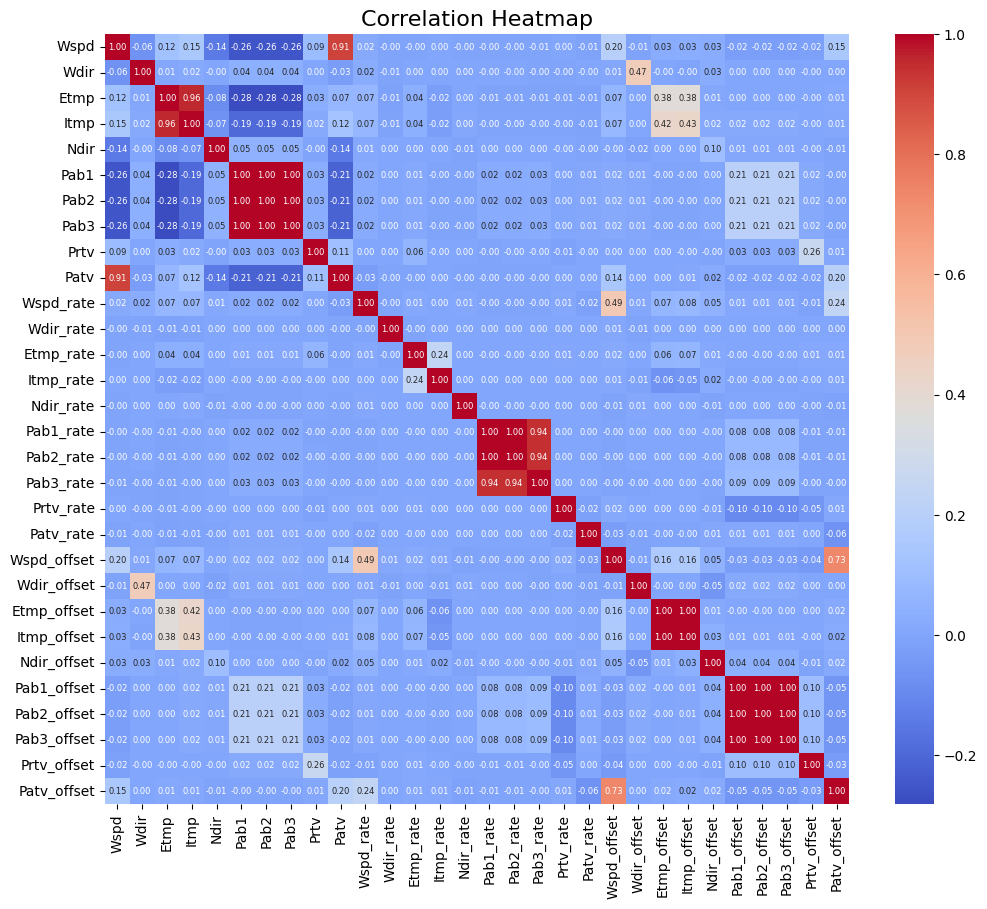

/tmp/ipykernel_56626/3924420644.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_sorted.index, y=correlations_sorted.values, palette='coolwarm')


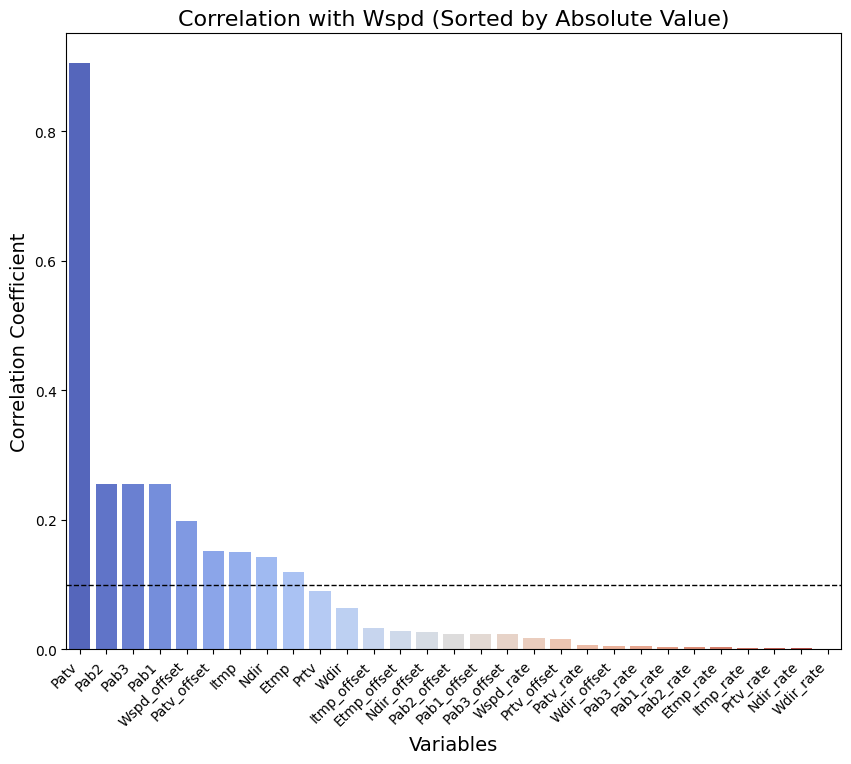

   Pab1  Pab2  Pab3  Wspd_offset  Wspd                 date
0   0.0   0.0   0.0        0.000  0.00  2024-01-01 00:00:00
1   1.0   1.0   1.0        0.000  6.17  2024-01-01 00:10:00
2   1.0   1.0   1.0        0.000  6.27  2024-01-01 00:20:00
3   1.0   1.0   1.0        0.000  6.42  2024-01-01 00:30:00
4   1.0   1.0   1.0        1.228  6.25  2024-01-01 00:40:00


/tmp/ipykernel_56626/3924420644.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['date'] = df['date']


In [6]:
# 计算相关性矩阵
corr = final_data.corr()

# 绘制热力图
plt.figure(figsize=(12, 10))  # 增加图的大小以提供更多空间
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 6})  # 增大注释字体大小
plt.title('Correlation Heatmap', fontsize=16)  # 增大标题字体大小
plt.show()

# 计算每个变量与Wspd的相关性
correlations = final_data.corr()['Wspd'].drop('Wspd')
# 根据绝对值大小排序
correlations_sorted = correlations.abs().sort_values(ascending=False)
# 绘制柱状图
plt.figure(figsize=(10, 8))
sns.barplot(x=correlations_sorted.index, y=correlations_sorted.values, palette='coolwarm')
plt.axhline(y=0.1, color='black', linestyle='--', linewidth=1)  # 添加y=0.1的水平线
plt.title('Correlation with Wspd (Sorted by Absolute Value)', fontsize=16)
plt.xlabel('Variables', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.xticks(rotation=45, ha='right')  # 旋转x轴标签以提高可读性
plt.show()

# 选择相关性绝对值大于0.1的列，包括Wspd自己，组成一个新的df
selected_columns = correlations[correlations.abs() >= 0.18].index.tolist()
selected_columns.append('Wspd')

# 从 final_data 中选择相关列
new_df = final_data[selected_columns] 
# 将 date 列从 df 中合并到 new_df
new_df['date'] = df['date']
new_df = new_df.drop(columns=['Patv'])
# 打印新的 DataFrame 的前几行
print(new_df.head())
# 将新的 DataFrame 保存到 CSV 文件
new_df.to_csv('filtered_data.csv', index=False)
